---
numbering:
  enumerator: "17.%s"
  headings: true
  equation:
    template: "%s"
---
(chap_design)=
# Design uncertainty and nonstandard errors

Every empirical result is the endpoint of a long chain of decisions. Which firms enter the sample? How are missing values handled? Where is the sorting threshold placed? How are portfolio positions weighted? None of these questions has a single defensible answer. Each one is a fork, and each fork multiplies the number of studies that could have been written from the same data.

The previous chapter treated uncertainty that comes from the data. This chapter treats uncertainty that comes from the analyst. The two are distinct. Sampling noise shrinks as observations accumulate, while the dispersion caused by methodological choices does not. A larger dataset does not tell you where to place a quantile cutoff.

We first formalize a research protocol as a sequence of choices, following @coqueret2026persistent. We then define the **nonstandard error**, introduced by @menkveld2021standard, and show how it can be separated from the standard error within a single variance decomposition. We close with a worked example on the value premium, where three simple choices generate eighteen defensible estimates of the same quantity.

(sec_design_forks)=
## The garden of forking paths

@gelman2014statistical describe the **garden of forking paths**: a researcher who analyzes a dataset makes many decisions that are contingent on the data, and the resulting result is one draw from a space of results that were never reported. The problem is not dishonesty. An analyst who runs a single specification and reports it faithfully still hides the variability that the unreported specifications would have revealed.

Two experimental designs have been used to map this space. In a **multi analyst study**, independent teams receive the same data and the same question. @silberzahn2018many gave 29 teams one dataset and asked whether soccer referees give more red cards to dark skinned players. The estimated effects ranged from no effect to a large one. @botviniknezer2020 repeated the exercise on a neuroimaging dataset with 70 teams and found that no two teams used the same analysis pipeline. @huntington2021influence document the same dispersion in applied microeconomics.

In a **multi path study**, a single team enumerates the choices explicitly and runs all of the combinations. @simonsohn2020specification call the resulting object a specification curve. In finance, @mitton2021methodological spans 1,024 paths in corporate finance, @soebhag2022mind and @walter2022non do so for portfolio sorts, @fieberg2024non for cryptocurrencies, and @battistella2025multiverse and @cakici2025lost across asset classes. The example in this chapter is a small multi path study.

### A protocol as a sequence of choices

Following @coqueret2026persistent, we model an empirical study as a composition of operations applied to a dataset $\mathbb{D}$. If the protocol has $J$ steps, the reported result is

```{math}
:label: eq_design_path
\hat{b} := \hat{b}(\mathbb{D}) = f_J \circ f_{J-1} \circ \dots \circ f_1(\mathbb{D}),
```

where $\hat{b}$ is the object of interest. It may be an average return, a $t$ statistic, or an alpha. Each step $f_j$ offers $r_j \ge 2$ defensible options, so the number of distinct **paths** is

```{math}
:label: eq_design_count
P = \prod_{j=1}^J r_j.
```

The multiplicative form is what makes this a practical concern. Seven binary or ternary choices already generate several hundred paths. @coqueret2026persistent use seven forks and obtain $P = 576$; @walter2022non use fourteen and obtain 69,120. Since each path yields its own estimate, we index outcomes by the path and write $\hat{b}_p$ for $p = 1, \dots, P$.

Two properties of this notation matter. First, $\hat{b}_p$ is random because $\mathbb{D}$ is random, so each path has a sampling distribution. Second, two paths that share many steps will produce similar answers on the same data. Both properties reappear below.

(sec_design_nse)=
## Standard and nonstandard errors

@menkveld2021standard coined the term **nonstandard error** for the dispersion in results that is attributable to the choices of the analyst rather than to the data. Their multi analyst study of market microstructure found these errors to be sizable, and comparable in magnitude to the standard errors that researchers habitually report.

The literature measures the nonstandard error either as the interquartile range of outcomes across paths (@menkveld2021standard, @walter2022non) or as their cross sectional standard deviation (@soebhag2022mind, @fieberg2024non). The standard error is measured separately, usually by bootstrapping the returns of each path after the paths have been run. The two quantities are therefore built on different reference objects and do not combine into anything.

@coqueret2026persistent close this gap. Suppose the analyst runs every path on several samples, so that each outcome $\hat{b}_p(\mathbb{D})$ is indexed by both a path $p$ and a sample $\mathbb{D}$. The law of total variance (see chapter 9 of @blitzstein2019introduction) can then be applied twice to the same quantity $\sigma_b^2 = \mathbb{V}[\hat{b}_p(\mathbb{D})]$. Conditioning on the sample gives

```{math}
:label: eq_design_ltv_sample
\sigma_b^2 = \mathbb{V}\big[\mathbb{E}[\hat{b}\,|\,\mathbb{D}]\big] + \mathbb{E}\big[\mathbb{V}[\hat{b}\,|\,\mathbb{D}]\big],
```

where the second term is the variance across paths within a sample, averaged over samples. That is the nonstandard error of the literature, with the refinement that it is averaged rather than computed on a single dataset. Conditioning on the path instead gives

```{math}
:label: eq_design_ltv_path
\sigma_b^2 = \mathbb{V}\big[\mathbb{E}[\hat{b}\,|\,p]\big] + \mathbb{E}\big[\mathbb{V}[\hat{b}\,|\,p]\big],
```

where the second term is the variance across samples within a path, averaged over paths. That is the standard error of the literature.

Both identities are valid and neither is preferable, so @coqueret2026persistent take one half of each pair:

```{math}
:label: eq_design_se
\text{SE} = \sqrt{\frac{\mathbb{E}\big[\mathbb{V}[\hat{b}\,|\,p]\big] + \mathbb{V}\big[\mathbb{E}[\hat{b}\,|\,\mathbb{D}]\big]}{2}},
```

```{math}
:label: eq_design_nse
\text{NSE} = \sqrt{\frac{\mathbb{V}\big[\mathbb{E}[\hat{b}\,|\,p]\big] + \mathbb{E}\big[\mathbb{V}[\hat{b}\,|\,\mathbb{D}]\big]}{2}}.
```

Adding {eq}`eq_design_ltv_sample` and {eq}`eq_design_ltv_path` and dividing by two shows that these definitions satisfy

```{math}
:label: eq_design_sum
\sigma_b^2 = \text{SE}^2 + \text{NSE}^2.
```

This is the appeal of the construction. The two errors are now shares of one budget, so the statement that methodological uncertainty dominates sampling uncertainty becomes a statement about a decomposition rather than a comparison of two unrelated numbers. We verify {eq}`eq_design_sum` numerically below.

(sec_design_corr)=
## Why correlation across paths matters

Having many estimates is only useful if they carry independent information. Let $\hat{\mu}_b = P^{-1}\sum_p \hat{b}_p$ be the average outcome across paths. Its variance is not $\sigma_b^2 / P$, because the outcomes are not independent:

```{math}
:label: eq_design_varmean
\sigma^2_{\hat{\mu}_b} = \frac{\sigma_b^2}{P^2}\sum_{1 \le p,q \le P} \rho_{p,q},
\qquad \rho_{p,q} = \mathbb{C}\text{or}\big(\hat{b}_p(\mathbb{D}), \hat{b}_q(\mathbb{D})\big).
```

Combining {eq}`eq_design_varmean` with {eq}`eq_design_sum` gives the canonical expression

```{math}
:label: eq_design_canonical
\sigma^2_{\hat{\mu}_b} = \big(\text{SE}^2 + \text{NSE}^2\big) \sum_{p,q} \frac{\rho_{p,q}}{P^2}.
```

Three quantities therefore drive the width of any confidence interval around the mean effect: the standard error, the nonstandard error, and the average correlation across paths. If the correlations were all zero, the last term would collapse to $1/P$ and adding paths would sharpen inference. If the correlations are close to one, the term stays close to one and the $P$ paths deliver no more information than a single one.

It may seem paradoxical that agreement across paths is undesirable. The resolution is that each path is a separate model learning from the data. Ideally all of them reach the same conclusion, but for different reasons. Agreement that emerges from different perspectives is evidence of robustness. Agreement that emerges because the paths are looking at the same rows of the same table is not. The same intuition underlies bagging and random forests, where the benefit of an ensemble comes from decorrelating its members (@breiman2001random), a point developed in Chapter {ref}`chap_ensemble`.

This suggests an operational fix. Analysts normally run every path on one fixed dataset, which we call **common resampling** when the exercise is repeated on perturbed versions of that dataset. @coqueret2026persistent instead recommend **path specific resampling**: draw a fresh sample immediately before running each path. The paths then no longer share their sampling noise, the correlations collapse toward zero, and the sum in {eq}`eq_design_canonical` falls to roughly $1/P$. In their study of 107 anomalies, the average correlation falls from about 0.17 to essentially zero, which narrows the confidence interval for the mean by a factor of about five.

(sec_design_nsr)=
## The nonstandard Sharpe ratio

If the nonstandard error measures how much an estimate moves when the protocol moves, then a return should be judged against it. @coqueret2026persistent define the **nonstandard Sharpe ratio** as the mean outcome scaled by the nonstandard error:

```{math}
:label: eq_design_nsr
\text{NSR} = \frac{\bar{r}}{\text{NSE}}, \qquad \bar{r} = \sum_{p=1}^P \omega_p r_p,
```

where $r_p$ is the average return of the portfolio built along path $p$ and the $\omega_p$ are weights that sum to one. Uniform weights $\omega_p = 1/P$ treat all paths as equally defensible. Unequal weights let the analyst favor the conventional specification and downweight exotic ones.

When each path is run once and correlations can be assumed away, the nonstandard error is simply the dispersion of outcomes across paths and the ratio becomes

```{math}
:label: eq_design_nsr_simple
\text{NSR} = \frac{\bar{r}}{\sqrt{\sum_{p=1}^P \omega_p (r_p - \bar{r})^2}}.
```

The interpretation parallels the Sharpe ratio, with cross path dispersion replacing time series volatility. A factor with a large average return can still have a low nonstandard Sharpe ratio if its performance depends on how it is built. Up to a scaling constant, the NSR is the $t$ statistic for testing whether the mean across paths differs from zero, so it doubles as a decision rule. @coqueret2026persistent call an anomaly **persistent** when it survives both sampling noise and methodological variation, and they find that persistence is determined almost entirely by the NSR, with a threshold near one. Of the 107 anomalies they examine, 26 are persistent under every configuration they test.

(sec_design_value)=
## A worked example: the value premium

@asness2013devil is the natural illustration. Their title, the devil in HML's details, refers to the fact that the value factor of @fama1993common is defined with annually updated book values matched to lagged prices, and that seemingly innocuous departures from that convention change the measured premium substantially. Value is a good test case precisely because the underlying idea, that cheap stocks outperform expensive ones, is simple and uncontested. Whatever dispersion we find comes from implementation, not from disagreement about the hypothesis.

We keep three forks, each with an obvious menu of options:

- **Sorting quantile**: the tails used for the two legs, at 10%, 20% or 30%. @chen2021open document that published studies mostly use quintiles or deciles, with no consensus.
- **Size filter**: whether the smallest firms are removed, and how many. We try no filter, dropping the smallest 5%, and dropping the smallest 10%. Small firms are illiquid and expensive to trade, and they dominate equally weighted portfolios.
- **Weighting**: equal weights or capitalization weights. @plyakha2021equal show that this choice alone changes the conclusion of asset pricing tests.

That gives $3 \times 3 \times 2 = 18$ designs. This is a deliberately small design space, so it runs in under a minute; the studies cited above span hundreds or thousands of paths.

In [1]:
%config InlineBackend.figure_formats = ['png', 'pdf']

In [2]:
# Required libraries
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()

# The characteristics of the book are uniformized cross-sectionally: each one is
# a rank in [0,1], recomputed every month. A low price-to-book rank flags a value
# stock, so the book-to-market rank is one minus the PB rank. Likewise, the size
# rank stands in for market capitalization.
panel = pd.DataFrame({
    'date': data_ml['date'].values,
    'bm':   1 - data_ml['PB'].values,           # book-to-market rank
    'size': data_ml['size_avg_252d'].values,    # capitalization rank
    'ret':  data_ml['R1M'].values,              # one month forward return
})

print(f"Observations : {len(panel):,}")
print(f"Months       : {panel['date'].nunique()}")
print(f"Stocks       : {data_ml['fsym_id'].nunique():,}")
print(f"Period       : {panel['date'].min().date()} to {panel['date'].max().date()}")

Observations : 365,050
Months       : 279
Stocks       : 1,950
Period       : 2002-01-31 to 2025-03-31


Because the ranks are uniform within each month, the two design steps are easy to express. A size floor of 0.05 removes exactly the smallest 5% of firms in every cross section. A sorting quantile of 0.10 puts the cheapest tenth in the long leg and the most expensive tenth in the short leg. The function below implements one design; the second function runs all eighteen and reuses the ranking, which depends on the size filter but not on the other two choices.

In [3]:
QUANTILES = [0.10, 0.20, 0.30]     # tails used for the long and short legs
FLOORS    = [0.00, 0.05, 0.10]     # share of the smallest firms removed
WEIGHTS   = ['EW', 'CW']           # equal versus capitalization weighted

DESIGNS = list(itertools.product(QUANTILES, FLOORS, WEIGHTS))
print(f"Forks: 3, paths: {len(DESIGNS)}")


def long_short(df, quantile, floor, weighting):
    """Monthly return series of the long-short portfolio of one design."""
    kept = df[df['size'] > floor]
    rank = kept.groupby('date')['bm'].rank(pct=True).values
    dates, ret, size = kept['date'].values, kept['ret'].values, kept['size'].values
    w = np.ones(len(kept)) if weighting == 'EW' else size

    legs = []
    for leg in (rank >= 1 - quantile, rank <= quantile):
        agg = pd.DataFrame({'date': dates[leg],
                            'num': (ret * w)[leg],
                            'den': w[leg]}).groupby('date').sum()
        legs.append(agg['num'] / agg['den'])
    return legs[0] - legs[1]


def all_designs(df):
    """Average long-short return of all 18 designs, on one sample."""
    out = {}
    for floor in FLOORS:
        kept = df[df['size'] > floor]
        rank = kept.groupby('date')['bm'].rank(pct=True).values
        dates, ret, size = kept['date'].values, kept['ret'].values, kept['size'].values
        for quantile in QUANTILES:
            top, bottom = rank >= 1 - quantile, rank <= quantile
            for weighting in WEIGHTS:
                w = np.ones(len(kept)) if weighting == 'EW' else size
                legs = []
                for leg in (top, bottom):
                    agg = pd.DataFrame({'date': dates[leg],
                                        'num': (ret * w)[leg],
                                        'den': w[leg]}).groupby('date').sum()
                    legs.append(agg['num'] / agg['den'])
                out[(quantile, floor, weighting)] = (legs[0] - legs[1]).mean()
    return out

Forks: 3, paths: 18


We now run the eighteen designs on the full sample. Returns are expressed in percent per month.

In [4]:
baseline = all_designs(panel)
b_full = np.array([baseline[d] for d in DESIGNS]) * 100

table = pd.DataFrame(DESIGNS, columns=['Quantile', 'Size floor', 'Weighting'])
table['Avg. return (%)'] = b_full.round(4)
table = table.sort_values('Avg. return (%)', ascending=False).reset_index(drop=True)
print(table.to_string(index=False))

print(f"\nmean {b_full.mean():.4f}   min {b_full.min():.4f}   "
      f"max {b_full.max():.4f}   ratio {b_full.max() / b_full.min():.1f}")

 Quantile  Size floor Weighting  Avg. return (%)
      0.2        0.00        CW           0.1749
      0.3        0.00        CW           0.1668
      0.3        0.05        EW           0.1654
      0.2        0.05        EW           0.1640
      0.2        0.10        EW           0.1620
      0.2        0.00        EW           0.1619
      0.3        0.10        EW           0.1608
      0.1        0.05        CW           0.1592
      0.2        0.05        CW           0.1565
      0.1        0.10        EW           0.1561
      0.3        0.05        CW           0.1561
      0.3        0.00        EW           0.1474
      0.2        0.10        CW           0.1470
      0.1        0.05        EW           0.1459
      0.3        0.10        CW           0.1436
      0.1        0.10        CW           0.1433
      0.1        0.00        CW           0.1412
      0.1        0.00        EW           0.0625

mean 0.1508   min 0.0625   max 0.1749   ratio 2.8


Every design produces a positive premium, so the sign of the effect is not in question. The magnitude is. The largest estimate is roughly 2.8 times the smallest, and the weakest design by a wide margin is the one that sorts on the extreme deciles, applies no size filter, and weights equally. This is the configuration in which the long leg loads most heavily on tiny illiquid firms, and it is exactly the sensitivity that @asness2013devil emphasize. An analyst who reported only that path, and an analyst who reported only the strongest path, would both be reporting a defensible number.

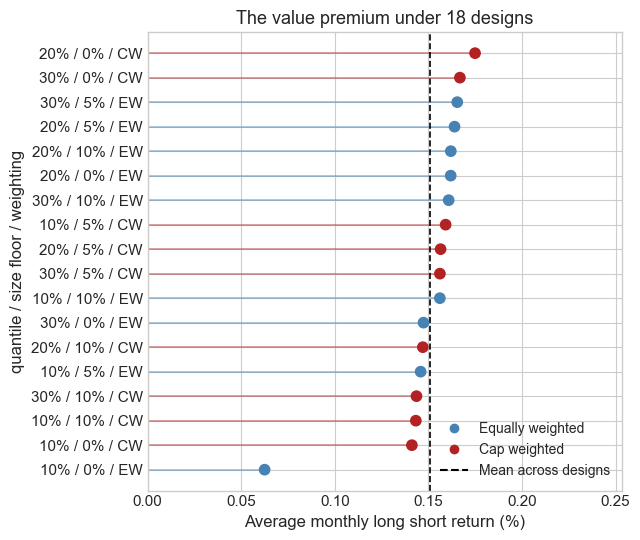

In [5]:
order  = np.argsort(b_full)
labels = [f"{d[0]:.0%} / {d[1]:.0%} / {d[2]}" for d in DESIGNS]
colors = ['steelblue' if d[2] == 'EW' else 'firebrick' for d in DESIGNS]

# The printed page reduces every figure, so the canvas is kept narrow and the
# type large. What looks oversized on screen is what stays readable in print.
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.hlines(range(18), 0, b_full[order], color=[colors[i] for i in order], lw=1.2, alpha=0.5)
ax.scatter(b_full[order], range(18), c=[colors[i] for i in order], s=55, zorder=3)
ax.axvline(b_full.mean(), color='black', linestyle='--', lw=1.2)

ax.set_yticks(range(18))
ax.set_yticklabels([labels[i] for i in order], fontsize=11)
ax.tick_params(axis='x', labelsize=11)
ax.set_xlabel('Average monthly long short return (%)', fontsize=12)
ax.set_ylabel('quantile / size floor / weighting', fontsize=12)
ax.set_title('The value premium under 18 designs', fontsize=13)
ax.set_xlim(0, b_full.max() * 1.45)
ax.legend(handles=[Line2D([], [], marker='o', ls='', color='steelblue', label='Equally weighted'),
                   Line2D([], [], marker='o', ls='', color='firebrick', label='Cap weighted'),
                   Line2D([], [], ls='--', color='black', label='Mean across designs')],
          loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### Resampling and the correlation across paths

We now repeat the exercise on perturbed versions of the data. Each sample is a random 40% of the stock month observations, drawn without replacement. Under **common resampling** one sample is drawn and all eighteen designs are run on it. Under **path specific resampling** a fresh sample is drawn immediately before each design. The two schemes differ only in the order of two lines, but that order determines whether the paths share their sampling noise.

In [6]:
rng       = np.random.default_rng(42)
N_SAMPLES = 50
FRACTION  = 0.40
n_rows    = len(panel)
n_draw    = int(FRACTION * n_rows)


def subsample():
    """A random 40% of the stock month observations, without replacement."""
    return panel.iloc[np.sort(rng.choice(n_rows, size=n_draw, replace=False))]


# Common resampling: draw one sample, then run every design on it.
rows = []
for _ in range(N_SAMPLES):
    outcome = all_designs(subsample())
    rows.append([outcome[d] for d in DESIGNS])
common = np.array(rows) * 100

# Path specific resampling: draw a new sample before each design.
specific = np.empty((N_SAMPLES, len(DESIGNS)))
for i in range(N_SAMPLES):
    for j, (quantile, floor, weighting) in enumerate(DESIGNS):
        specific[i, j] = long_short(subsample(), quantile, floor, weighting).mean() * 100

print(f"Outcome matrices: {common.shape} (samples x paths)")


def average_correlation(M):
    """Average of the off-diagonal correlations across paths."""
    C = np.corrcoef(M, rowvar=False)
    P = C.shape[0]
    return (C.sum() - np.trace(C)) / (P * (P - 1)), C


rho_common, C_common = average_correlation(common)
rho_spec,   C_spec   = average_correlation(specific)

print(f"Average correlation, common resampling   : {rho_common:+.3f}")
print(f"Average correlation, path specific       : {rho_spec:+.3f}")

Outcome matrices: (50, 18) (samples x paths)
Average correlation, common resampling   : +0.689
Average correlation, path specific       : -0.010


The contrast is stark. Sharing a sample across designs induces an average correlation near 0.69, while drawing a separate sample for each design brings it to zero. Recall from {eq}`eq_design_canonical` that the relevant quantity is $\sum_{p,q}\rho_{p,q}/P^2$, which equals $1/P + (1 - 1/P)\bar{\rho}$ when the correlations are homogeneous. With $P = 18$ this is about 0.71 under common resampling and about 0.05 under path specific resampling, a difference of more than a factor of ten in the variance of the mean.

We now apply the decomposition of {eq}`eq_design_se` and {eq}`eq_design_nse`. Because the outcomes form a balanced grid of samples by paths, the population variances (with `ddof=0`) satisfy the additivity of {eq}`eq_design_sum` exactly, which the code checks.

In [7]:
def decompose(M):
    """Split the variance of the effect into a standard and a nonstandard error."""
    v_across_paths   = M.var(axis=1, ddof=0).mean()   # E[V[b | D]]
    v_of_sample_mean = M.mean(axis=1).var(ddof=0)     # V[E[b | D]]
    v_across_samples = M.var(axis=0, ddof=0).mean()   # E[V[b | p]]
    v_of_path_mean   = M.mean(axis=0).var(ddof=0)     # V[E[b | p]]
    se  = np.sqrt((v_across_samples + v_of_sample_mean) / 2)
    nse = np.sqrt((v_of_path_mean + v_across_paths) / 2)
    return se, nse


for name, M, rho in [('common', common, rho_common),
                     ('path specific', specific, rho_spec)]:
    se, nse = decompose(M)
    P = M.shape[1]
    corr_term = 1 / P + (1 - 1 / P) * rho          # sum of rho_pq divided by P^2
    sigma_mu  = np.sqrt((se ** 2 + nse ** 2) * corr_term)
    print(f"{name:14s} SE {se:.4f}  NSE {nse:.4f}  "
          f"SE2+NSE2 {se ** 2 + nse ** 2:.6f} vs total variance {M.var(ddof=0):.6f}")
    print(f"{'':14s} correlation term {corr_term:.3f}  "
          f"standard deviation of the mean {sigma_mu:.4f}")

common         SE 0.0602  NSE 0.0333  SE2+NSE2 0.004735 vs total variance 0.004735
               correlation term 0.706  standard deviation of the mean 0.0578
path specific  SE 0.0581  NSE 0.0569  SE2+NSE2 0.006608 vs total variance 0.006608
               correlation term 0.046  standard deviation of the mean 0.0174


The additivity of {eq}`eq_design_sum` holds to the last digit, as it must. The economically relevant line is the last one: the standard deviation of the mean effect falls from about 0.058 to about 0.017 when resampling is done path by path. The estimate of the average premium is unchanged, but the precision with which we know it improves by a factor of more than three.

Note also that the standard error and the nonstandard error are of comparable size here. That is a consequence of the small design space. With only three forks the paths are close relatives of one another, so their dispersion is limited, while a 40% subsample injects a substantial amount of sampling noise. @coqueret2026persistent span 576 paths and find the nonstandard error to be an order of magnitude larger than the standard error for most anomalies. The nonstandard error grows with the number of forks, so a study that enumerates more choices will attribute more of its total variance to methodology.

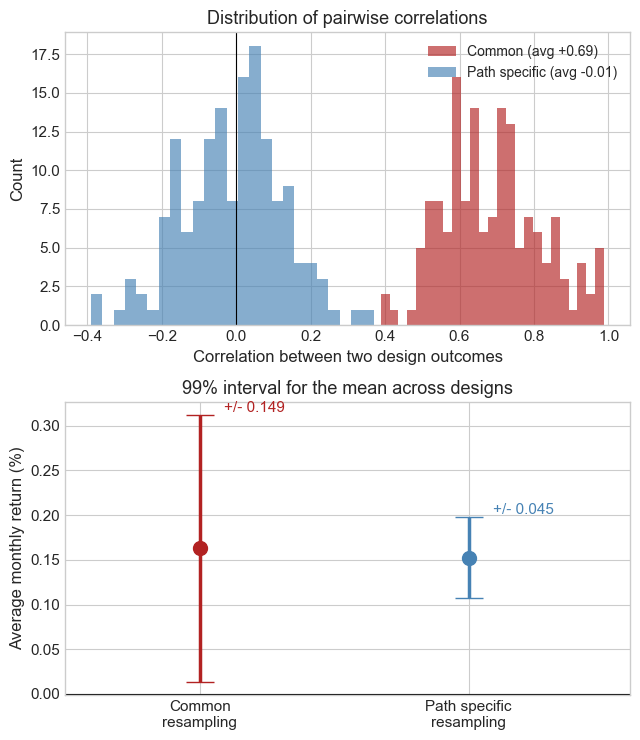

In [8]:
iu = np.triu_indices(18, k=1)

# Two stacked panels rather than two side by side: each one then keeps the full
# width of the figure, which survives the reduction applied on the printed page.
fig, axes = plt.subplots(2, 1, figsize=(6.5, 7.5))

# Top: distribution of the pairwise correlations under the two schemes
ax = axes[0]
ax.hist(C_common[iu], bins=25, alpha=0.65, color='firebrick',
        label=f'Common (avg {rho_common:+.2f})')
ax.hist(C_spec[iu], bins=25, alpha=0.65, color='steelblue',
        label=f'Path specific (avg {rho_spec:+.2f})')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlation between two design outcomes', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of pairwise correlations', fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10)

# Bottom: resulting interval for the mean across designs
ax = axes[1]
z = 2.576                                   # normal approximation, 99% level
for k, (name, M, rho, col) in enumerate([('Common\nresampling', common, rho_common, 'firebrick'),
                                         ('Path specific\nresampling', specific, rho_spec, 'steelblue')]):
    se, nse  = decompose(M)
    P        = M.shape[1]
    sigma_mu = np.sqrt((se ** 2 + nse ** 2) * (1 / P + (1 - 1 / P) * rho))
    ax.errorbar([k], [M.mean()], yerr=[z * sigma_mu], fmt='o', color=col,
                capsize=10, lw=2.5, ms=10)
    ax.text(k + 0.09, M.mean() + z * sigma_mu, f'+/- {z * sigma_mu:.3f}',
            va='bottom', fontsize=11, color=col)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Common\nresampling', 'Path specific\nresampling'], fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylabel('Average monthly return (%)', fontsize=12)
ax.set_title('99% interval for the mean across designs', fontsize=13)
ax.set_xlim(-0.5, 1.6)
plt.tight_layout()
plt.show()

The top panel shows two well separated distributions. Under common resampling almost every pair of designs has a correlation above 0.4, and many exceed 0.8. Under path specific resampling the correlations are symmetric around zero and concentrated in a narrow band, which is what one would obtain from independent series estimated on 50 observations. The bottom panel translates this into the interval that a reader would use. Both intervals exclude zero, so the value premium survives, but only the narrow one is informative about magnitude.

### Which choice matters most?

A multi path study should also report how each individual fork moves the result. The standard diagnostic is a conditional average: fix one option, average over everything else, and compare. We add the nonstandard Sharpe ratio of {eq}`eq_design_nsr_simple`, computed on the full sample with uniform weights.

In [9]:
nse_single = b_full.std(ddof=0)               # cross path dispersion, uniform weights
print(f"Mean across designs : {b_full.mean():.4f} % per month")
print(f"Nonstandard error   : {nse_single:.4f}")
print(f"NSR                 : {b_full.mean() / nse_single:.2f}")

print("\nConditional averages, in percent per month:")
for label, options, position in [('Quantile  ', QUANTILES, 0),
                                 ('Size floor', FLOORS, 1),
                                 ('Weighting ', WEIGHTS, 2)]:
    parts = [f"{str(o):>5}: {b_full[[d[position] == o for d in DESIGNS]].mean():.4f}"
             for o in options]
    print(f"  {label}  " + "   ".join(parts))

Mean across designs : 0.1508 % per month
Nonstandard error   : 0.0233
NSR                 : 6.47

Conditional averages, in percent per month:
  Quantile      0.1: 0.1347     0.2: 0.1610     0.3: 0.1567
  Size floor    0.0: 0.1424    0.05: 0.1578     0.1: 0.1521
  Weighting      EW: 0.1473      CW: 0.1543


The nonstandard Sharpe ratio is far above the threshold of one that @coqueret2026persistent associate with persistence. On this sample and against these three choices, the value premium is robust: no defensible combination of the three forks makes it disappear.

The conditional averages identify the sorting quantile as the most consequential fork. Moving from the extreme deciles to the extreme quintiles raises the average premium by roughly a fifth. This is the opposite of the usual intuition, which holds that sharper sorts isolate stronger signals. The explanation is that the extreme deciles are thin, so their returns are noisy and dominated by small firms. The size filter and the weighting scheme matter less on average, but recall from the table that they interact: the size filter is what rescues the equally weighted decile sort. Conditional averages summarize a fork in isolation and can hide interactions of this kind, which is a reason to report the full distribution alongside them.

(sec_design_practice)=
## Practical guidance

Multi path analysis is now cheap enough that it should be the default for any empirical claim about an anomaly. Four recommendations follow from the material above.

- **Enumerate the forks before looking at the results.** Writing the design space down first turns implicit degrees of freedom into an explicit object. It also removes the temptation described by @chen2021phacking, since a path that is chosen after the fact is no longer one draw from a declared space.
- **Resample before running each path, not after.** This is the single change with the largest effect on inference. It costs one extra line of code and it is what makes the number of paths work in your favor.
- **Report the distribution, not only its center.** A boxplot or a specification curve of the outcomes conveys the magnitude of design uncertainty. The mean alone conceals it, which is what the exercise above is meant to show.
- **Scale the effect by the nonstandard error.** The nonstandard Sharpe ratio answers the question a reader actually has, namely whether the result would survive in someone else's hands.

The broader literature on replication in finance reaches compatible conclusions. @hou2020replicating find that a majority of published anomalies weaken considerably under a uniform protocol, while @jensen2021there argue that most survive once the protocol is chosen carefully, and @perignon2022reproducibility report that only about half of a sample of finance papers can be reproduced from their own code and data. These studies disagree about how much of the factor zoo is real. Multi design analysis reframes the disagreement: rather than asking which single protocol is correct, it measures how much the answer depends on the question.

## Exercises

1. Add a fourth fork to the example: the holding period, with monthly and quarterly rebalancing. Recompute the 36 designs and report the new nonstandard Sharpe ratio. Does adding a fork raise the nonstandard error, and by how much?

2. Replace the value characteristic by momentum (`mom_252`) and run the same eighteen designs. Compare the nonstandard Sharpe ratio of momentum with that of value. Which anomaly is more sensitive to design choices?

3. Vary the resampling fraction from 0.2 to 0.9 while keeping the path specific scheme. Plot the estimated SE and NSE against the fraction. Explain why one of the two curves is far more stable than the other.

4. Implement the non uniform weighting of {eq}`eq_design_nsr`. Take the design with a 20% quantile, a 5% size floor and capitalization weights as the baseline, and give every other path a weight proportional to $0.75^{d}$, where $d$ is the number of choices that differ from the baseline. How does the weighted mean compare with the uniform one?

5. Using the outcome matrix from common resampling, compute the correlation between each pair of designs and regress it on the number of steps the two designs share. Verify that commonality between paths predicts correlation between outcomes.

6. Conceptually, the paths in this chapter are all sorted portfolios. Suppose instead that the object of interest is the out of sample $R^2$ of a machine learning forecast, as in Chapter {ref}`chap_valtune`. List five forks that a researcher would face, and explain which of them you would expect to generate the largest nonstandard error.